In [1]:
from bertopic import BERTopic
import numpy as np

# 加载保存的模型
topic_model = BERTopic.load('bertopic_model')

# 如果你想进行需要 Embedding 的分析（如可视化文档散点图），
# 还需要加载你之前保存的 numpy 向量或重新生成。
embeddings = np.load('embeddings.npy')

/opt/homebrew/Caskroom/miniconda/base/envs/hate_master_thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-13 13:45:25,881 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.


In [5]:
import os
print(os.getcwd()) # 获取当前工作目录
print(os.listdir()) # 查看当前目录下都有啥

/Users/noriaki/Documents/GitHub/Master_Thesis/unsupervised_classification/topic_modeling_results/models
['embeddings.npy', 'view_model.ipynb', 'bertopic_model']


In [6]:
# 生成层次树状图
import pandas as pd
tokenized_docs = pd.read_csv('../data/processed_corpus.csv')['tokenized_text']
hierarchical_topics = topic_model.hierarchical_topics(tokenized_docs)
fig_hierarchy = topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)
fig_hierarchy.write_html('../visualizations/hierarchy.html')

100%|██████████| 3/3 [00:00<00:00, 134.41it/s]


In [8]:
import matplotlib.font_manager as fm
import os

def detect_cjk_fonts():
    print("正在扫描系统中的中日文字体...")
    
    # 获取系统中所有 TrueType 字体路径
    font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
    
    # 按照优先级排序寻找关键词：
    # CJK (中日韩), WQY (文泉驿), Noto (谷歌), Sim (黑体/宋体), Takao (日文)
    priority_keywords = ['wqy', 'noto', 'cjk', 'sim', 'takao', 'ipa', 'droid', 'han']
    
    found_fonts = []
    for path in font_list:
        filename = os.path.basename(path).lower()
        if any(key in filename for key in priority_keywords):
            found_fonts.append(path)
    
    if found_fonts:
        print(f"找到 {len(found_fonts)} 个潜在可用的 CJK 字体：")
        for i, f in enumerate(found_fonts[:5]): # 只展示前5个
            print(f" [{i}] {f}")
        return found_fonts[0] # 返回匹配度最高的一个
    else:
        print("未在系统中检测到预装的中日文字体。")
        return None

# 执行检测
best_font = detect_cjk_fonts()

if best_font:
    print(f"\n建议在 WordCloud 中使用路径: font_path='{best_font}'")
else:
    print("\n[方案 B] 请执行以下命令安装字体：")
    print("!apt-get install -y fonts-wqy-microhei")

正在扫描系统中的中日文字体...
找到 119 个潜在可用的 CJK 字体：
 [0] /System/Library/Fonts/NotoNastaliq.ttc
 [1] /System/Library/Fonts/Supplemental/NotoSansWancho-Regular.ttf
 [2] /System/Library/Fonts/Supplemental/NotoSansLydian-Regular.ttf
 [3] /System/Library/Fonts/Supplemental/NotoSansPhagsPa-Regular.ttf
 [4] /System/Library/Fonts/Supplemental/NotoSansNewa-Regular.ttf

建议在 WordCloud 中使用路径: font_path='/System/Library/Fonts/NotoNastaliq.ttc'


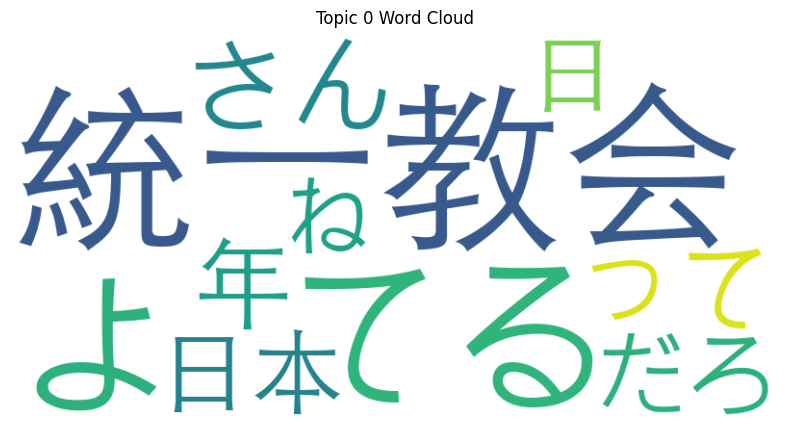

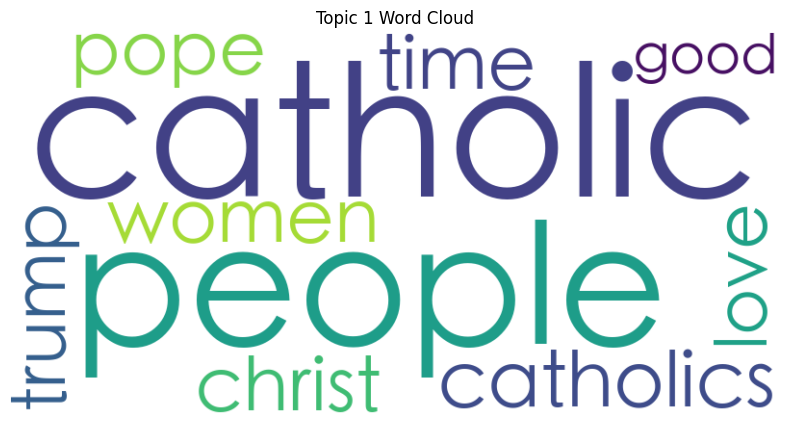

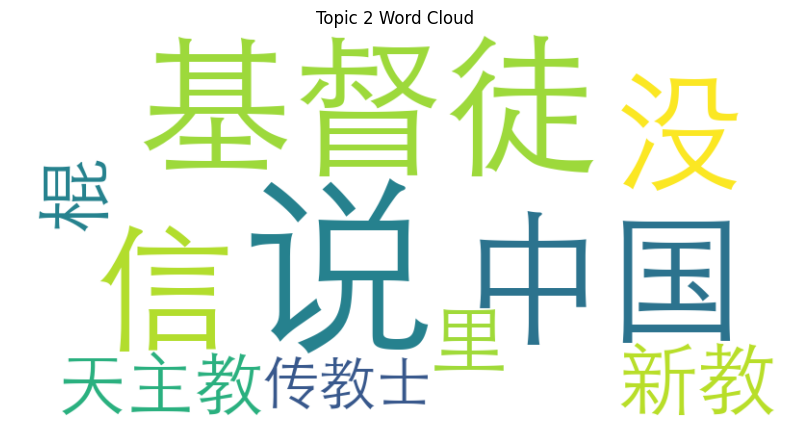

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def save_wordclouds(topic_model, n_topics=3):
    for i in range(n_topics): # -1 是噪声，从 0 开始
        words = {word: weight for word, weight in topic_model.get_topic(i)}
        wc = WordCloud(width=800, height=400, background_color='white', font_path='/System/Library/Fonts/STHeiti Light.ttc') # 注意中文字体
        wc.generate_from_frequencies(words)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis("off")
        plt.title(f"Topic {i} Word Cloud")
        plt.show()
        plt.savefig(f'../visualizations/wordcloud_topic_{i}.png')
        plt.close()

save_wordclouds(topic_model)